### Logistic Regression

In [1]:
# Imports
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_blobs

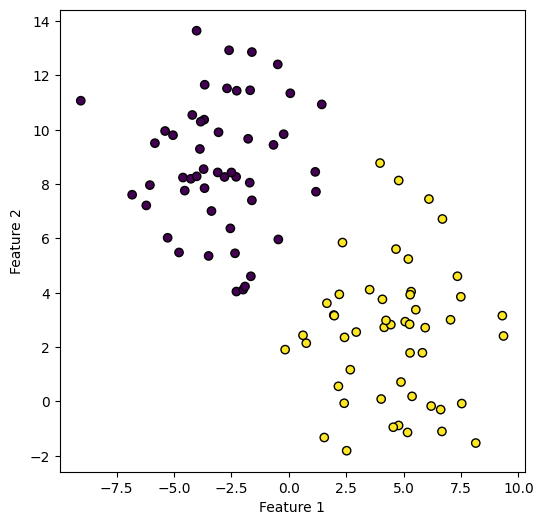

In [2]:
# Create dataset
x, y = make_blobs(n_samples=100,  centers=2, cluster_std=2.5,
                           random_state=42)
# Plot
plt.figure(figsize = (6, 6))
plt.scatter(x[:, 0], x[:, 1], c=y, edgecolors='k')
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [3]:
# Logistic Regression Model
np.random.seed(42)

# Sigmoid
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Params
w = np.zeros((x.shape[1], 1))
b = 0.0
lr = 0.1
num_epochs = 1000

n = x.shape[0]
y = y.reshape(-1, 1)

# Training loop
for epoch in range(num_epochs):
    # Forward
    z = x @ w + b
    a = sigmoid(z)

    # Loss
    eps = 1e-8
    loss = -np.mean(y*np.log(a + eps) + (1-y)*np.log(1-a + eps))

    # Backward
    grad_w = (x.T @ (a - y)) / n
    grad_b = np.mean(a - y)

    # Update
    w -= lr * grad_w
    b -= lr * grad_b

    if epoch % 100 == 0:
        print(f"Epoch {epoch} | Loss: {loss:.4f}")

Epoch 0 | Loss: 0.6931
Epoch 100 | Loss: 0.0487
Epoch 200 | Loss: 0.0387
Epoch 300 | Loss: 0.0339
Epoch 400 | Loss: 0.0308
Epoch 500 | Loss: 0.0285
Epoch 600 | Loss: 0.0266
Epoch 700 | Loss: 0.0251
Epoch 800 | Loss: 0.0238
Epoch 900 | Loss: 0.0226


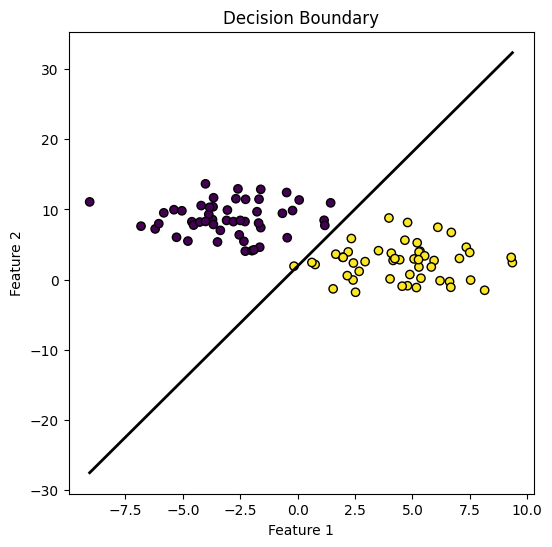

In [4]:
# Plot decision boundary
w1, w2 = w[0,0], w[1,0]

plt.figure(figsize=(6,6))
plt.scatter(x[:, 0], x[:, 1], c=y, edgecolors='k')

x_values = np.linspace(x[:, 0].min(), x[:, 0].max(), 100)
y_values = -(w1 * x_values + b) / w2

plt.plot(x_values, y_values, color='black', linewidth=2)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Decision Boundary")
plt.show()

### Softmax Regression

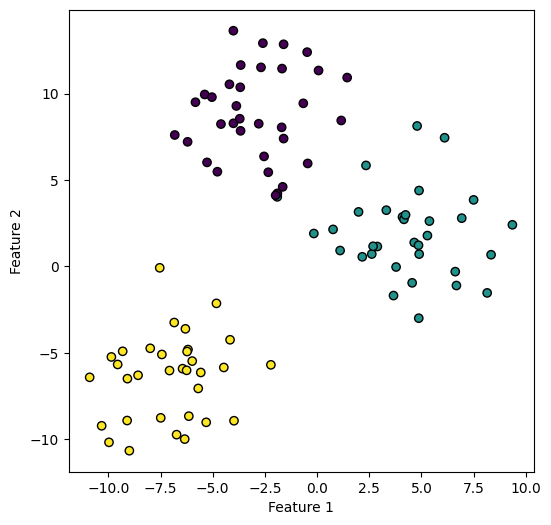

In [5]:
# Create new dataset with 3 classes
x_sr, y_sr = make_blobs(n_samples=100,  centers=3, cluster_std=2.5,
                           random_state=42)
# Plot
plt.figure(figsize = (6, 6))
plt.scatter(x_sr[:, 0], x_sr[:, 1], c=y_sr, edgecolors='k')
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [6]:
# Softmax Regression Model
np.random.seed(42)

# Softmax
def softmax(z):
    z = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

# Create one-hot encoded form of y_sr
num_classes = 3
y_sr_one_hot = np.zeros((y_sr.shape[0], num_classes))
y_sr_one_hot[np.arange(y_sr.shape[0]), y_sr] = 1

# Params
w_sr = np.zeros((x_sr.shape[1], num_classes))
b_sr = np.zeros((1, num_classes))
lr = 0.01
num_epochs = 1000

n = x_sr.shape[0]

# Training loop
for epoch in range(num_epochs):
    # Forward
    z = x_sr @ w_sr + b_sr
    a = softmax(z)

    # Loss (cross-entropy)
    eps = 1e-8
    loss = -np.mean(np.sum(y_sr_one_hot * np.log(a + eps), axis=1))

    # Backward
    grad_w = (x_sr.T @ (a - y_sr_one_hot)) / n
    grad_b = np.mean(a - y_sr_one_hot, axis=0)

    # Update
    w_sr -= lr * grad_w
    b_sr -= lr * grad_b

    if epoch % 100 == 0:
        print(f"Epoch {epoch} | Loss: {loss:.4f}")

Epoch 0 | Loss: 1.0986
Epoch 100 | Loss: 0.1307
Epoch 200 | Loss: 0.1015
Epoch 300 | Loss: 0.0900
Epoch 400 | Loss: 0.0835
Epoch 500 | Loss: 0.0793
Epoch 600 | Loss: 0.0763
Epoch 700 | Loss: 0.0739
Epoch 800 | Loss: 0.0720
Epoch 900 | Loss: 0.0704


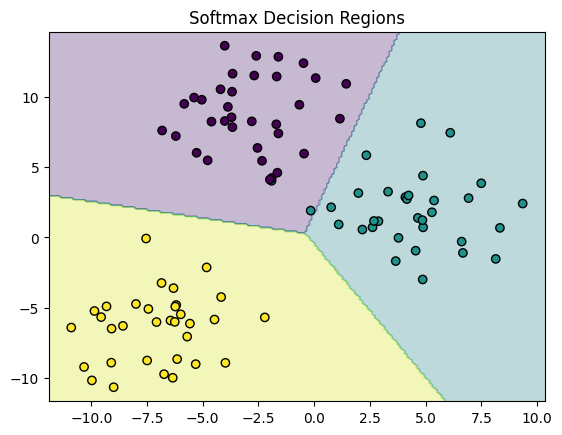

In [7]:
# Create grid
x_min, x_max = x_sr[:, 0].min() - 1, x_sr[:, 0].max() + 1
y_min, y_max = x_sr[:, 1].min() - 1, x_sr[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

# Flatten grid
grid = np.c_[xx.ravel(), yy.ravel()]

# Predict
z = grid @ w_sr + b_sr
a = softmax(z)
preds = np.argmax(a, axis=1)

# Reshape
Z = preds.reshape(xx.shape)

# Plot regions
plt.contourf(xx, yy, Z, alpha=0.3)

# Plot data
plt.scatter(x_sr[:, 0], x_sr[:, 1], c=y_sr, edgecolors='k')

plt.title("Softmax Decision Regions")
plt.show()